In [1]:
## Loading required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [2]:
# Loading data 
df = pd.read_csv('C:/Users/UserIBM/Documents/Student_Performance.csv')

In [3]:
# First few rows of the dataset
print(df.head())

   student_id  age  gender school_type parent_education  study_hours  \
0           1   14    male      public    post graduate          3.1   
1           2   18  female      public         graduate          3.7   
2           3   17  female     private    post graduate          7.9   
3           4   16   other      public      high school          1.1   
4           5   16  female      public      high school          1.3   

   attendance_percentage internet_access travel_time extra_activities  \
0                   84.3             yes     <15 min              yes   
1                   87.8             yes     >60 min               no   
2                   65.5              no     <15 min               no   
3                   58.1              no   15-30 min               no   
4                   61.0             yes   30-60 min              yes   

  study_method  math_score  science_score  english_score  overall_score  \
0        notes        42.7           55.4           5

In [4]:
# Shape of the dataset
print(df.shape)

(25000, 16)


In [8]:
##### Exploratory data Analysis 

In [3]:
### for specific Plot Style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["font.size"] = 11

In [4]:
# Create binary target variable 
df['pass_fail'] = np.where(df['overall_score'] >= 50, 'Pass', 'Fail')
print(df['pass_fail'].value_counts())

pass_fail
Pass    18389
Fail     6611
Name: count, dtype: int64


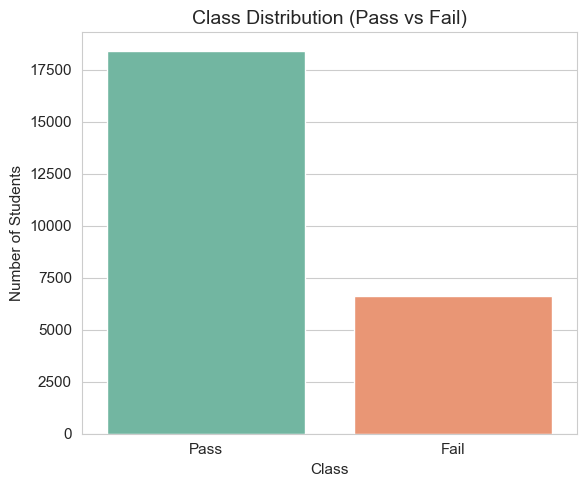

pass_fail
Pass    73.556
Fail    26.444
Name: proportion, dtype: float64


In [13]:
### check for class imbalance 
plt.figure(figsize=(6,5))
sns.countplot(
    data=df,
    x='pass_fail',
    hue='pass_fail',
    palette='Set2',
    legend=False
)
plt.title("Class Distribution (Pass vs Fail)", fontsize=14)
plt.xlabel("Class")
plt.ylabel("Number of Students")
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x()+p.get_width()/2,
                 p.get_height()),
                ha='center',
                va='bottom')
plt.tight_layout()
plt.show()
# Percentage
class_percent = df['pass_fail'].value_counts(normalize=True)*100
print(class_percent)

In [5]:
### Encoding Target for Correlation Analysis
df_corr = df.copy()
le = LabelEncoder()
df_corr['pass_fail'] = le.fit_transform(df_corr['pass_fail'])
categorical_cols = [
    'gender',
    'school_type',
    'parent_education',
    'internet_access',
    'travel_time',
    'extra_activities',
    'study_method',
    'final_grade'
]
for col in categorical_cols:
    df_corr[col] = LabelEncoder().fit_transform(df_corr[col])

In [6]:
print(df_corr.head())

   student_id  age  gender  school_type  parent_education  study_hours  \
0           1   14       1            1                 5          3.1   
1           2   18       0            1                 1          3.7   
2           3   17       0            0                 5          7.9   
3           4   16       2            1                 2          1.1   
4           5   16       0            1                 2          1.3   

   attendance_percentage  internet_access  travel_time  extra_activities  \
0                   84.3                1            2                 1   
1                   87.8                1            3                 0   
2                   65.5                0            2                 0   
3                   58.1                0            0                 0   
4                   61.0                1            1                 1   

   study_method  math_score  science_score  english_score  overall_score  \
0             3       

In [7]:
### Feature Correlation with Target
corr = df_corr.corr(numeric_only=True)
target_corr = corr['pass_fail'].sort_values(ascending=False)
print(target_corr)

pass_fail                1.000000
overall_score            0.763170
study_hours              0.696782
science_score            0.683982
math_score               0.683307
english_score            0.681890
attendance_percentage    0.213532
internet_access          0.009189
travel_time              0.005020
extra_activities         0.003719
study_method             0.003332
parent_education        -0.000856
age                     -0.004177
school_type             -0.006168
student_id              -0.009040
gender                  -0.009556
final_grade             -0.712615
Name: pass_fail, dtype: float64


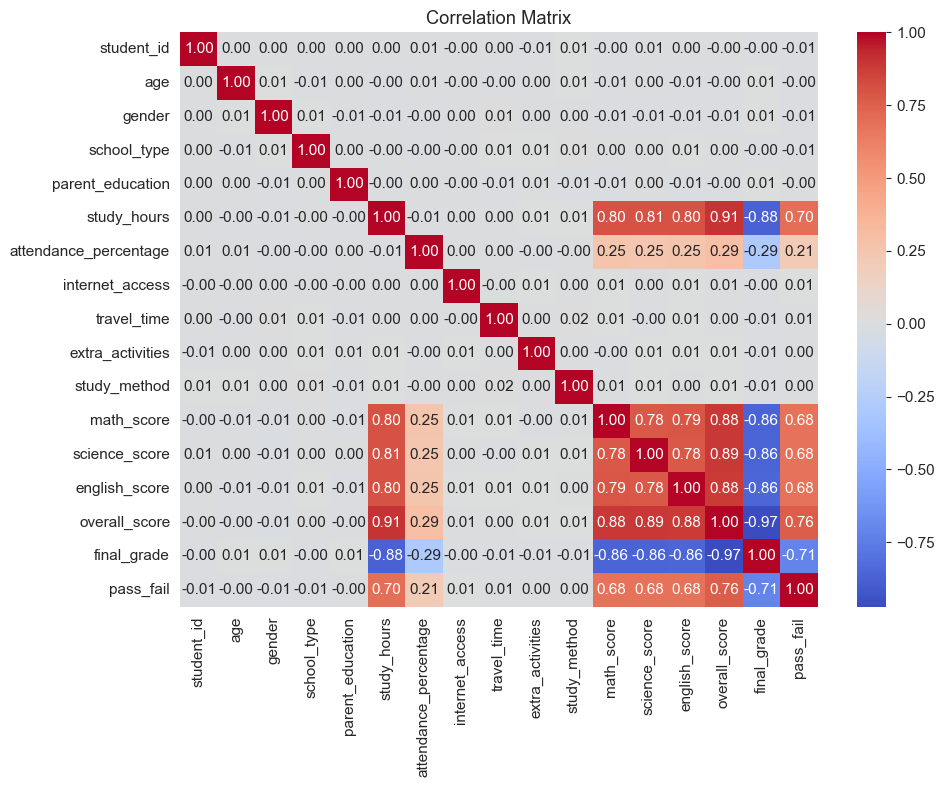

In [17]:
### Correlation map 
plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

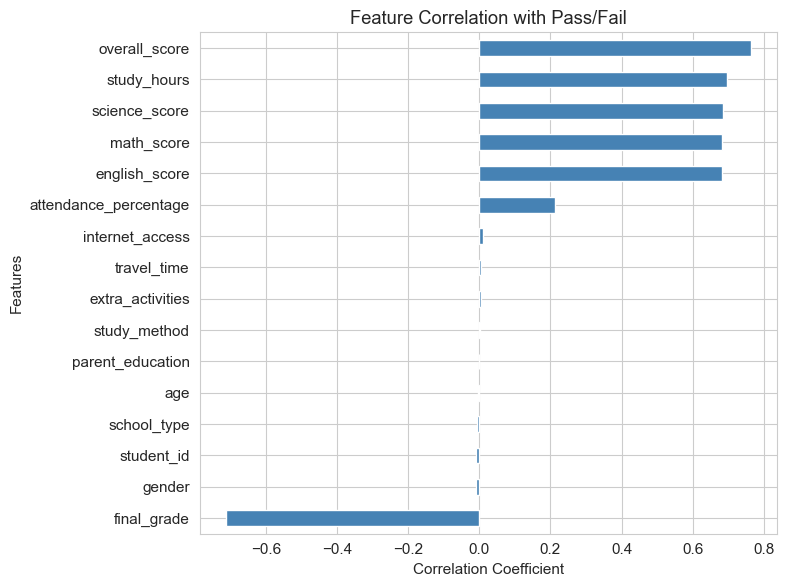

In [18]:
### Explaoring Top Features Correlated with Target varaible 
target_corr = target_corr.drop('pass_fail')
plt.figure(figsize=(8,6))
target_corr.sort_values().plot(
    kind='barh',
    color='steelblue'
)
plt.title("Feature Correlation with Pass/Fail")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

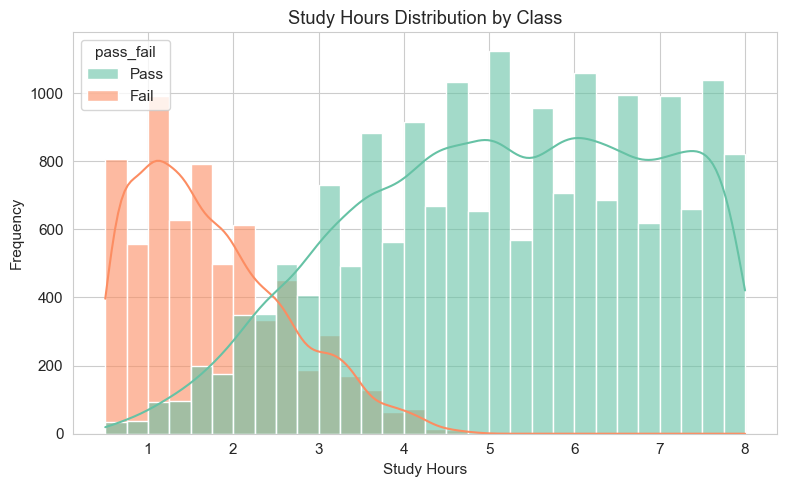

In [19]:
### Study Hours Distribution by Class
plt.figure(figsize=(8,5))
sns.histplot(
    data=df,
    x='study_hours',
    hue='pass_fail',
    kde=True,
    palette='Set2',
    alpha=0.6
)
plt.title("Study Hours Distribution by Class")
plt.xlabel("Study Hours")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

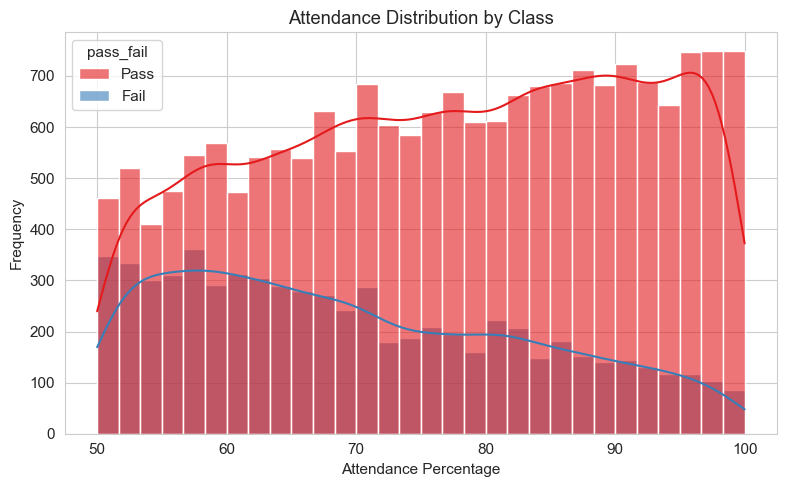

In [20]:
### Attendance Distribution by Class
plt.figure(figsize=(8,5))
sns.histplot(
    data=df,
    x='attendance_percentage',
    hue='pass_fail',
    kde=True,
    palette='Set1',
    alpha=0.6
)
plt.title("Attendance Distribution by Class")
plt.xlabel("Attendance Percentage")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

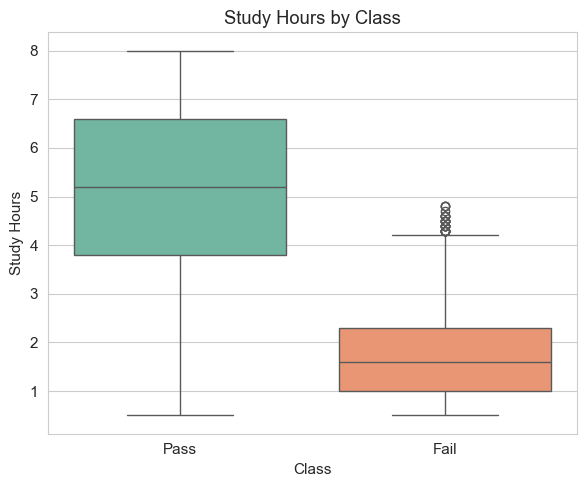

In [23]:
### Boxplot (Study Hours vs Pass/Fail)
plt.figure(figsize=(6,5))
sns.boxplot(
    data=df,
    x='pass_fail',
    y='study_hours',
    hue='pass_fail',
    palette='Set2',
    legend=False
)
plt.title("Study Hours by Class")
plt.xlabel("Class")
plt.ylabel("Study Hours")
plt.tight_layout()
plt.show()

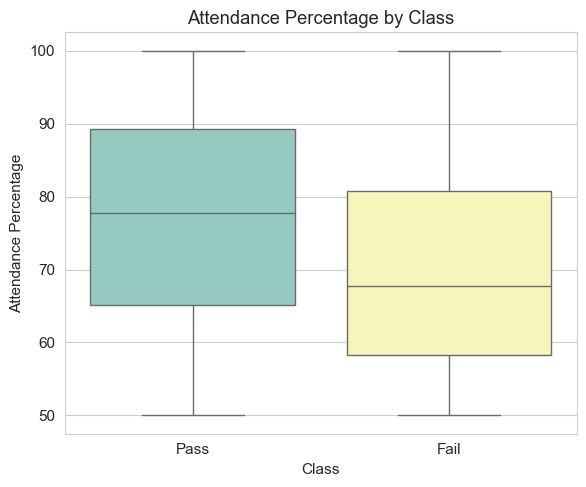

In [25]:
### Boxplot (Attendance vs Pass/Fail)
plt.figure(figsize=(6,5))
sns.boxplot(
    data=df,
    x='pass_fail',
    y='attendance_percentage',
    hue='pass_fail',
    palette='Set3',
    legend=False
)
plt.title("Attendance Percentage by Class")
plt.xlabel("Class")
plt.ylabel("Attendance Percentage")
plt.tight_layout()
plt.show()

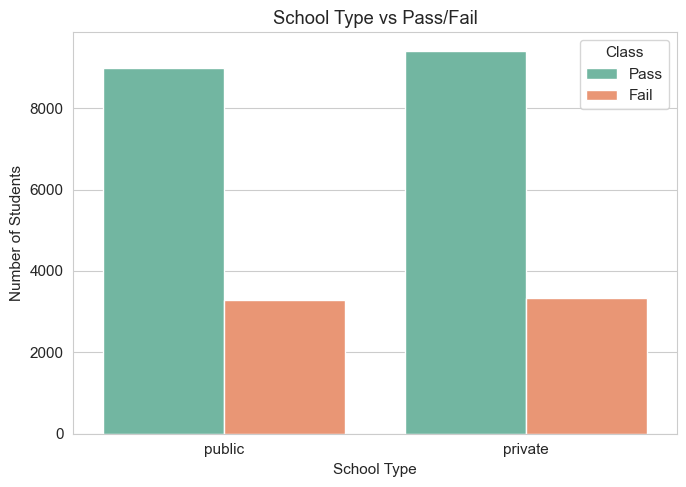

In [27]:
## School Type vs Class
plt.figure(figsize=(7,5))
sns.countplot(
    data=df,
    x='school_type',
    hue='pass_fail',
    palette='Set2'
)
plt.title("School Type vs Pass/Fail")
plt.xlabel("School Type")
plt.ylabel("Number of Students")
plt.legend(title="Class")
plt.tight_layout()
plt.show()

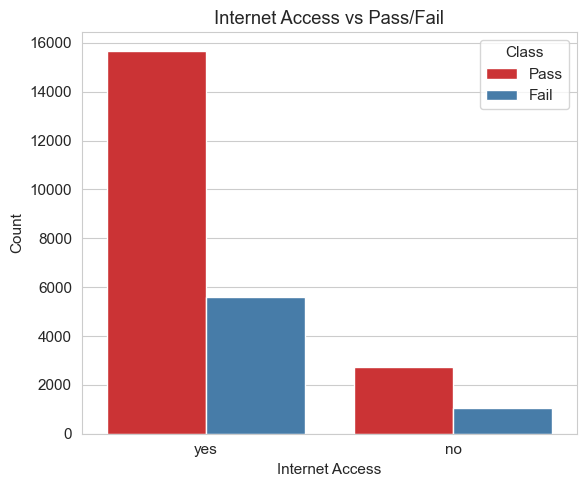

In [28]:
#### Internet Access vs Class
plt.figure(figsize=(6,5))
sns.countplot(
    data=df,
    x='internet_access',
    hue='pass_fail',
    palette='Set1'
)
plt.title("Internet Access vs Pass/Fail")
plt.xlabel("Internet Access")
plt.ylabel("Count")
plt.legend(title="Class")
plt.tight_layout()
plt.show()

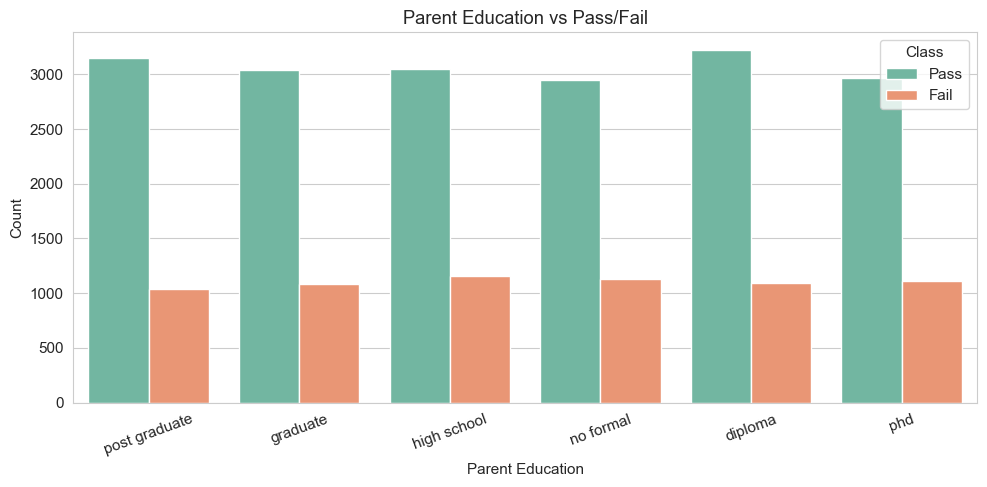

In [30]:
### Parent Education vs Class
plt.figure(figsize=(10,5))
sns.countplot(
    data=df,
    x='parent_education',
    hue='pass_fail',
    palette='Set2'
)
plt.title("Parent Education vs Pass/Fail")
plt.xlabel("Parent Education")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.legend(title="Class")
plt.tight_layout()
plt.show()

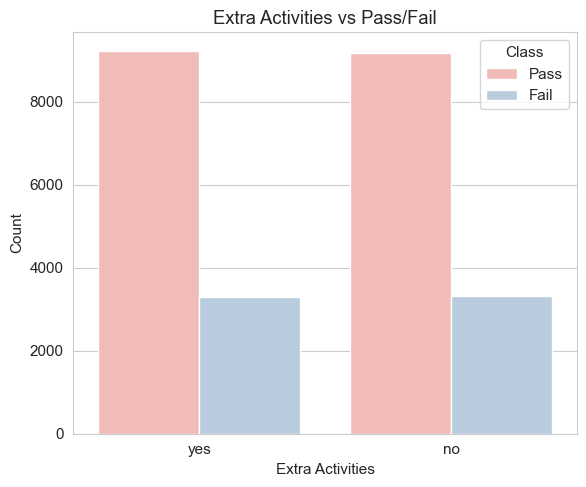

In [31]:
### Extra Activities vs Class
plt.figure(figsize=(6,5))
sns.countplot(
    data=df,
    x='extra_activities',
    hue='pass_fail',
    palette='Pastel1'
)
plt.title("Extra Activities vs Pass/Fail")
plt.xlabel("Extra Activities")
plt.ylabel("Count")
plt.legend(title="Class")
plt.tight_layout()
plt.show()

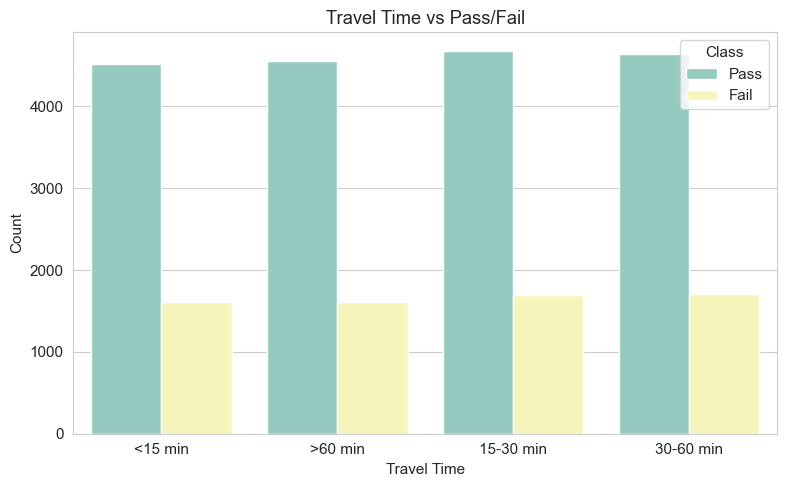

In [33]:
### Travel Time vs Class
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x='travel_time',
    hue='pass_fail',
    palette='Set3'
)
plt.title("Travel Time vs Pass/Fail")
plt.xlabel("Travel Time")
plt.ylabel("Count")
plt.legend(title="Class")
plt.tight_layout()
plt.show()

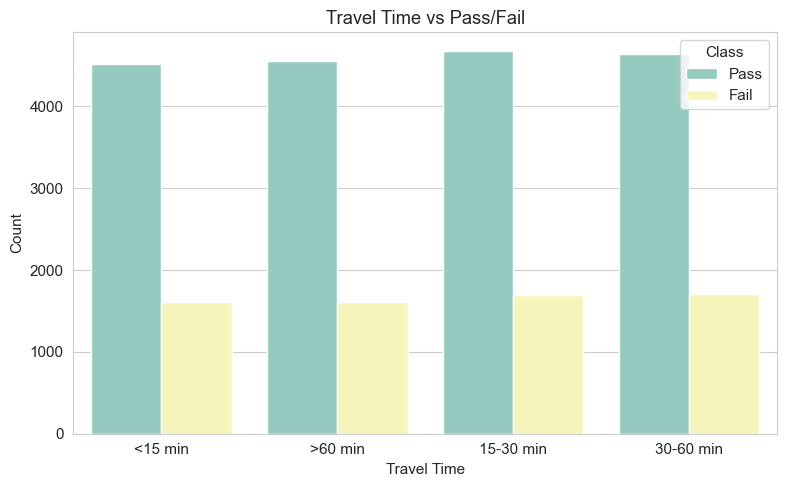

In [34]:
### Travel Time vs Class
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x='travel_time',
    hue='pass_fail',
    palette='Set3'
)
plt.title("Travel Time vs Pass/Fail")
plt.xlabel("Travel Time")
plt.ylabel("Count")
plt.legend(title="Class")
plt.tight_layout()
plt.show()

In [8]:
### Overall Summary Table 
summary = df.groupby('pass_fail')[[
    'study_hours',
    'attendance_percentage',
    'math_score',
    'science_score',
    'english_score',
    'overall_score'
]].mean()
print(summary.round(2))

           study_hours  attendance_percentage  math_score  science_score  \
pass_fail                                                                  
Fail              1.73                  69.97       40.00          39.82   
Pass              5.16                  76.92       72.34          72.35   

           english_score  overall_score  
pass_fail                                
Fail               40.04          39.91  
Pass               72.18          72.67  


In [9]:
# Check missing values
print(df.isnull().sum())

student_id               0
age                      0
gender                   0
school_type              0
parent_education         0
study_hours              0
attendance_percentage    0
internet_access          0
travel_time              0
extra_activities         0
study_method             0
math_score               0
science_score            0
english_score            0
overall_score            0
final_grade              0
pass_fail                0
dtype: int64


In [10]:
### creating new feature 
df['average_subject_score'] = (
    df['math_score'] +
    df['science_score'] +
    df['english_score']
) / 3
# Display the new feature
print(df['average_subject_score'])

0        51.700000
1        63.733333
2        86.333333
3        42.200000
4        23.866667
           ...    
24995    50.333333
24996    55.100000
24997    35.633333
24998    18.166667
24999    32.700000
Name: average_subject_score, Length: 25000, dtype: float64


In [11]:
### creating another new feature 
df['study_efficiency'] = (
    df['overall_score'] /
    (df['study_hours'] + 1)
)
# Display the new feature
print(df['study_efficiency'])

0        12.951220
1        13.042553
2        10.067416
3        19.809524
4        11.043478
           ...    
24995    16.464286
24996    15.270270
24997    18.350000
24998    17.050000
24999    18.470588
Name: study_efficiency, Length: 25000, dtype: float64


In [12]:
### Encode Target Variable
le = LabelEncoder()
df['pass_fail'] = le.fit_transform(df['pass_fail'])
# Display first 10 encoded values of targeted variable 
print("Encoded Target Variable:")
print(df['pass_fail'].head(10))


Encoded Target Variable:
0    1
1    1
2    1
3    0
4    0
5    1
6    0
7    1
8    1
9    1
Name: pass_fail, dtype: int32


In [13]:
### One-Hot Encode Categorical Features
categorical_features = [
    'gender',
    'school_type',
    'parent_education',
    'internet_access',
    'travel_time',
    'extra_activities',
    'study_method',
    'final_grade'
]
df = pd.get_dummies(
    df,
    columns=categorical_features,
    drop_first=True
)
print("Columns after One-Hot Encoding:\n")
print(df.columns.tolist())

Columns after One-Hot Encoding:

['student_id', 'age', 'study_hours', 'attendance_percentage', 'math_score', 'science_score', 'english_score', 'overall_score', 'pass_fail', 'average_subject_score', 'study_efficiency', 'gender_male', 'gender_other', 'school_type_public', 'parent_education_graduate', 'parent_education_high school', 'parent_education_no formal', 'parent_education_phd', 'parent_education_post graduate', 'internet_access_yes', 'travel_time_30-60 min', 'travel_time_<15 min', 'travel_time_>60 min', 'extra_activities_yes', 'study_method_group study', 'study_method_mixed', 'study_method_notes', 'study_method_online videos', 'study_method_textbook', 'final_grade_b', 'final_grade_c', 'final_grade_d', 'final_grade_e', 'final_grade_f']


In [14]:
### Remove Student ID
df.drop('student_id', axis=1, inplace=True)

In [15]:
### Separate Features and Target
X = df.drop('pass_fail', axis=1)
y = df['pass_fail']

# Display feature matrix
print("Feature Matrix (X):")
print(X.head())

# Display target variable
print("\nTarget Variable (y):")
print(y.head())

# Display shapes
print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

Feature Matrix (X):
   age  study_hours  attendance_percentage  math_score  science_score  \
0   14          3.1                   84.3        42.7           55.4   
1   18          3.7                   87.8        57.6           68.8   
2   17          7.9                   65.5        84.8           95.0   
3   16          1.1                   58.1        44.4           27.5   
4   16          1.3                   61.0         8.9           32.7   

   english_score  overall_score  average_subject_score  study_efficiency  \
0           57.0           53.1              51.700000         12.951220   
1           64.8           61.3              63.733333         13.042553   
2           79.2           89.6              86.333333         10.067416   
3           54.7           41.6              42.200000         19.809524   
4           30.0           25.4              23.866667         11.043478   

   gender_male  ...  study_method_group study  study_method_mixed  \
0         True 

In [18]:
### Scale Numerical Features
scaler = StandardScaler()

numerical_features = [
    'age',
    'study_hours',
    'attendance_percentage',
    'math_score',
    'science_score',
    'english_score',
    'overall_score',
    'average_subject_score',
    'study_efficiency'
]

X[numerical_features] = scaler.fit_transform(
    X[numerical_features]
)

In [19]:
print("Feature Matrix Shape:", X.shape)

print("Target Shape:", y.shape)

X.head()

Feature Matrix Shape: (25000, 32)
Target Shape: (25000,)


,age,study_hours,attendance_percentage,math_score,science_score,english_score,overall_score,average_subject_score,study_efficiency,gender_male,...,study_method_group study,study_method_mixed,study_method_notes,study_method_online videos,study_method_textbook,final_grade_b,final_grade_c,final_grade_d,final_grade_e,final_grade_f
0,-1.457138,-0.532053,0.641202,-1.010113,-0.397963,-0.321367,-0.576082,-0.622964,-0.087154,True,...,False,False,True,False,False,False,False,False,True,False
1,0.890472,-0.255236,0.884716,-0.296335,0.241042,0.053772,-0.142944,-0.000228,-0.062138,False,...,False,False,False,False,True,False,False,True,False,False
2,0.303569,1.682482,-0.666817,1.006669,1.490439,0.746337,1.351907,1.169343,-0.877016,False,...,False,False,True,False,False,True,False,False,False,False
3,-0.283333,-1.454776,-1.181675,-0.928675,-1.728428,-0.431985,-1.183530,-1.114598,1.791307,False,...,False,False,True,False,False,False,False,False,True,False
4,-0.283333,-1.362504,-0.979907,-2.629286,-1.480456,-1.619926,-2.039240,-2.063365,-0.609676,False,...,True,False,False,False,False,False,False,False,False,True


In [20]:
### removing the features containing direct information to avoid target leakage
X = df.drop([
    'pass_fail',
    'overall_score',
    'study_efficiency',
    'final_grade_b',
    'final_grade_c',
    'final_grade_d',
    'final_grade_e',
    'final_grade_f'
], axis=1)

y = df['pass_fail']

In [21]:
X.head()

,age,study_hours,attendance_percentage,math_score,science_score,english_score,average_subject_score,gender_male,gender_other,school_type_public,...,internet_access_yes,travel_time_30-60 min,travel_time_<15 min,travel_time_>60 min,extra_activities_yes,study_method_group study,study_method_mixed,study_method_notes,study_method_online videos,study_method_textbook
0,14,3.1,84.3,42.7,55.4,57.0,51.700000,True,False,True,...,True,False,True,False,True,False,False,True,False,False
1,18,3.7,87.8,57.6,68.8,64.8,63.733333,False,False,True,...,True,False,False,True,False,False,False,False,False,True
2,17,7.9,65.5,84.8,95.0,79.2,86.333333,False,False,False,...,False,False,True,False,False,False,False,True,False,False
3,16,1.1,58.1,44.4,27.5,54.7,42.200000,False,True,True,...,False,False,False,False,False,False,False,True,False,False
4,16,1.3,61.0,8.9,32.7,30.0,23.866667,False,False,True,...,True,True,False,False,True,True,False,False,False,False


In [23]:
### spliting data (80/20)
from sklearn.model_selection import train_test_split
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)
# Display shapes
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)

Training Features: (20000, 25)
Testing Features : (5000, 25)
Training Labels : (20000,)
Testing Labels  : (5000,)


In [28]:
### Training ML models ( Logistic Regression, Decision Tree, Random Forest, and XGBoost)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

# creating ML models
### Logistic regression model 
lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)
### Decision tree
dt = DecisionTreeClassifier(
    random_state=42
)
### Random forest model 
rf = RandomForestClassifier(
    random_state=42
)
### Gradient Boosting
gb = GradientBoostingClassifier(
    random_state=42
)

# Train ML models
lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)
print("All models trained successfully")

# Predict ML models
# Logistic Regression
lr_pred = lr.predict(X_test)
# Decision Tree
dt_pred = dt.predict(X_test)
# Random Forest
rf_pred = rf.predict(X_test)
# Gradient Boosting
gb_pred = gb.predict(X_test)
print("Predictions completed.")

All models trained successfully
Predictions completed.


In [29]:
#### Evaluation metrices 
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
results = pd.DataFrame(columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC AUC"
])
models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "Gradient Boosting": gb
}
predictions = {
    "Logistic Regression": lr_pred,
    "Decision Tree": dt_pred,
    "Random Forest": rf_pred,
    "Gradient Boosting": gb_pred
}
for name in models:
    y_pred = predictions[name]
    y_prob = models[name].predict_proba(X_test)[:,1]
    results.loc[len(results)] = [
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ]
results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.9494,0.962463,0.969005,0.965723,0.989717
1,Decision Tree,0.9700,0.974960,0.984502,0.979708,0.957077
2,Random Forest,0.9794,0.985075,0.986949,0.986011,0.997349
3,Gradient Boosting,0.9524,0.966377,0.969005,0.967689,0.991321


In [30]:
### choosing the best model 
best_model_name = results.loc[
    results["Accuracy"].idxmax(),
    "Model"
]
print("Best Model:", best_model_name)

Best Model: Random Forest


<Figure size 600x500 with 0 Axes>

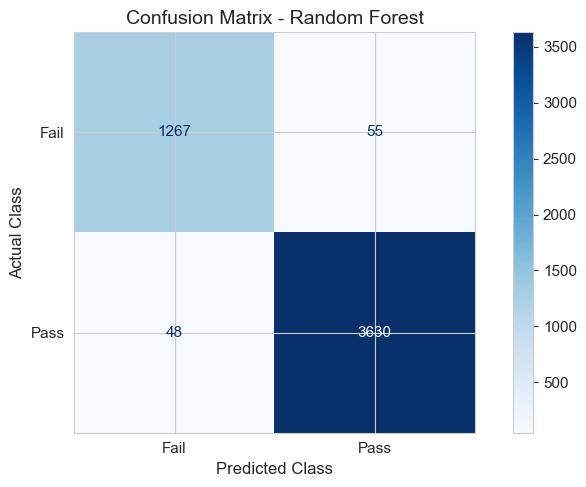

In [31]:
# ==========================================================
# Confusion Matrix - Best Model (Random Forest)
# ==========================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate Confusion Matrix
cm = confusion_matrix(y_test, rf_pred)

# Plot
plt.figure(figsize=(6,5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fail", "Pass"]
)

disp.plot(cmap="Blues", values_format='d')

plt.title("Confusion Matrix - Random Forest", fontsize=14)
plt.xlabel("Predicted Class", fontsize=12)
plt.ylabel("Actual Class", fontsize=12)

plt.tight_layout()
plt.show()

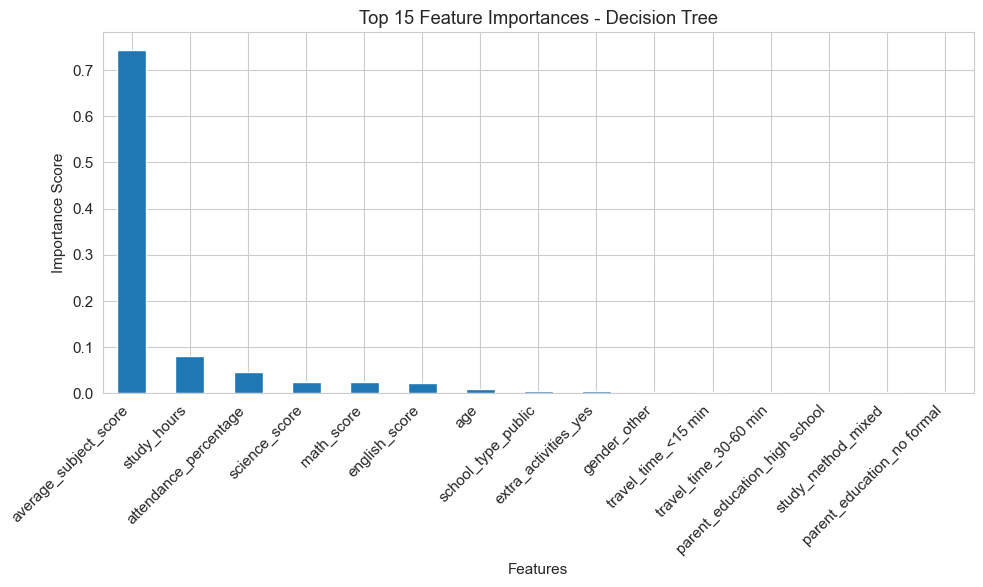

In [32]:
# ==========================================================
# Feature Importance - Decision Tree
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt

dt_importance = pd.Series(
    dt.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))

dt_importance.head(15).plot(kind='bar')

plt.title("Top 15 Feature Importances - Decision Tree")
plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

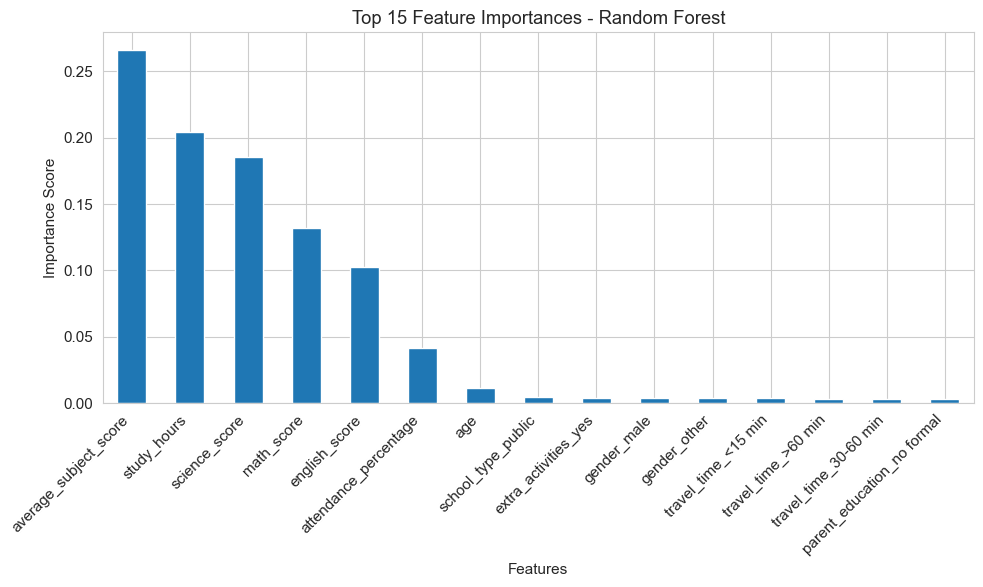

In [33]:
# ==========================================================
# Feature Importance - Random Forest
# ==========================================================

rf_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))

rf_importance.head(15).plot(kind='bar')

plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

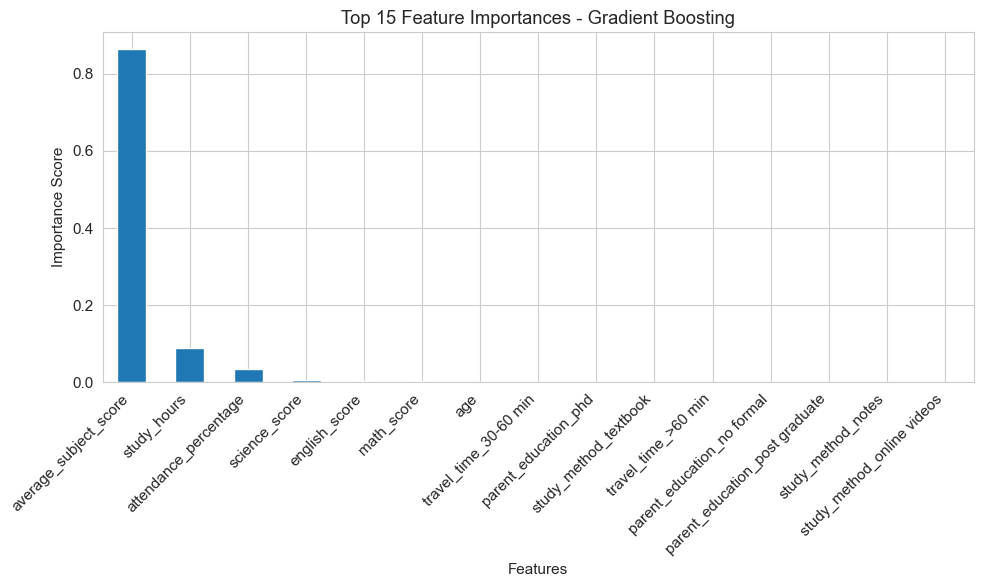

In [34]:
# ==========================================================
# Feature Importance - Gradient Boosting
# ==========================================================

gb_importance = pd.Series(
    gb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))

gb_importance.head(15).plot(kind='bar')

plt.title("Top 15 Feature Importances - Gradient Boosting")
plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

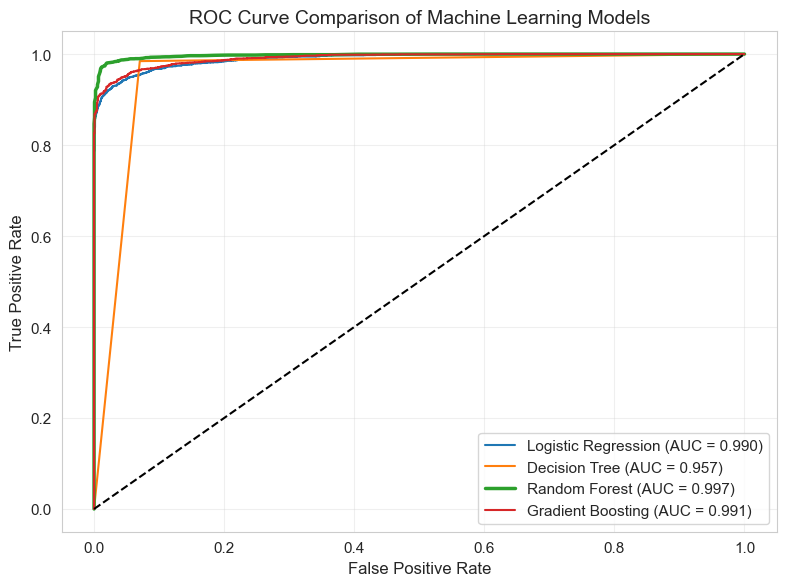

In [35]:
# ==========================================================
# ROC Curves - Comparison of All Models
# ==========================================================

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Predicted probabilities
lr_prob = lr.predict_proba(X_test)[:,1]
dt_prob = dt.predict_proba(X_test)[:,1]
rf_prob = rf.predict_proba(X_test)[:,1]
gb_prob = gb.predict_proba(X_test)[:,1]

# ROC values
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_prob)

# AUC
lr_auc = auc(lr_fpr, lr_tpr)
dt_auc = auc(dt_fpr, dt_tpr)
rf_auc = auc(rf_fpr, rf_tpr)
gb_auc = auc(gb_fpr, gb_tpr)

# Plot
plt.figure(figsize=(8,6))

plt.plot(lr_fpr, lr_tpr,
         label=f'Logistic Regression (AUC = {lr_auc:.3f})')

plt.plot(dt_fpr, dt_tpr,
         label=f'Decision Tree (AUC = {dt_auc:.3f})')

plt.plot(rf_fpr, rf_tpr,
         label=f'Random Forest (AUC = {rf_auc:.3f})',
         linewidth=2.5)

plt.plot(gb_fpr, gb_tpr,
         label=f'Gradient Boosting (AUC = {gb_auc:.3f})')

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)

plt.title("ROC Curve Comparison of Machine Learning Models", fontsize=14)

plt.legend(loc='lower right')

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [41]:
##3 Import GridSearchCV
from sklearn.model_selection import GridSearchCV
# ==========================================================
# ==========================================================
# Hyperparameter Grid for Random Forest
# ==========================================================

param_grid = {

    'n_estimators': [50, 100, 150],

    'max_depth': [10, 20, None],

    'min_samples_split': [2, 5, 10]

}

In [42]:
# ==========================================================
# GridSearchCV - Random Forest Hyperparameter Tuning
# ==========================================================

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

grid_search = GridSearchCV(

    estimator=RandomForestClassifier(
        random_state=42
    ),

    param_grid=param_grid,

    cv=5,

    scoring='accuracy',

    n_jobs=-1,

    verbose=2

)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 150]},
             scoring='accuracy', verbose=2)

In [43]:
# Best Hyperparameters

print("Best Parameters:\n")

print(grid_search.best_params_)

print("\nBest Cross Validation Accuracy:")

print(round(grid_search.best_score_,4))

Best Parameters:

{'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 50}

Best Cross Validation Accuracy:
0.9727


In [44]:
# Best Random Forest Model (Best Tuned Model)

best_rf = grid_search.best_estimator_

best_rf

RandomForestClassifier(max_depth=20, n_estimators=50, random_state=42)

In [45]:
# Predictions Using Tuned Model

tuned_pred = best_rf.predict(X_test)

tuned_prob = best_rf.predict_proba(X_test)[:,1]

In [46]:
### Evaluate Tuned Model
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Tuned Random Forest Performance\n")

print("Accuracy :", round(accuracy_score(y_test, tuned_pred),4))

print("Precision:", round(precision_score(y_test, tuned_pred),4))

print("Recall   :", round(recall_score(y_test, tuned_pred),4))

print("F1-Score :", round(f1_score(y_test, tuned_pred),4))

print("ROC-AUC  :", round(roc_auc_score(y_test, tuned_prob),4))

Tuned Random Forest Performance

Accuracy : 0.9798
Precision: 0.9869
Recall   : 0.9856
F1-Score : 0.9863
ROC-AUC  : 0.9972


In [47]:
###Compare Tuned vs Untuned Performance
# ==========================================================
# Performance Comparison
# ==========================================================

comparison = pd.DataFrame({

    'Metric':[
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score',
        'ROC AUC'
    ],

    'Untuned Random Forest':[

        accuracy_score(y_test, rf_pred),

        precision_score(y_test, rf_pred),

        recall_score(y_test, rf_pred),

        f1_score(y_test, rf_pred),

        roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])

    ],

    'Tuned Random Forest':[

        accuracy_score(y_test, tuned_pred),

        precision_score(y_test, tuned_pred),

        recall_score(y_test, tuned_pred),

        f1_score(y_test, tuned_pred),

        roc_auc_score(y_test, tuned_prob)

    ]

})

comparison

,Metric,Untuned Random Forest,Tuned Random Forest
0,Accuracy,0.979400,0.979800
1,Precision,0.985075,0.986932
2,Recall,0.986949,0.985590
3,F1 Score,0.986011,0.986260
4,ROC AUC,0.997349,0.997241


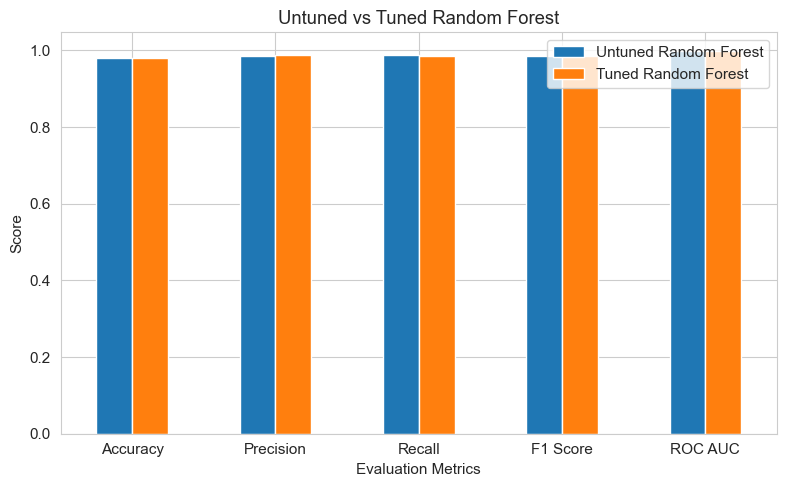

In [48]:
#### Visual Comparison
# ==========================================================
# Tuned vs Untuned Performance
# ==========================================================

comparison.set_index('Metric').plot(

    kind='bar',

    figsize=(8,5)

)

plt.title("Untuned vs Tuned Random Forest")

plt.ylabel("Score")

plt.xlabel("Evaluation Metrics")

plt.xticks(rotation=0)

plt.legend()

plt.tight_layout()

plt.show()